# Trabajo Practico 3 - Vision por Computadora

Detector final para encontrar el logotipo de la gaseosa dentro de las imagenes provistas.

## Consignas
1. Obtener una deteccion del logo en cada imagen sin falsos positivos.
2. Plantear y validar un algoritmo para multiples detecciones en `coca_multi.png` con el mismo template.
3. Generalizar el algoritmo anterior a todas las imagenes.

## 1. Carga de datos y configuracion

In [ ]:
from pathlib import Path

import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np


def find_tp3_dir():
    """Busca la carpeta TP3 para que el notebook funcione desde distintas ubicaciones."""
    candidates = [
        Path.cwd(),
        Path.cwd() / 'TP3',
        Path.cwd().parent / 'TP3',
        Path.cwd().parent.parent / 'TP3',
    ]
    for candidate in candidates:
        if (candidate / 'template' / 'pattern.png').exists():
            return candidate.resolve()
    return Path.cwd().resolve()


base_dir = find_tp3_dir()
images_dir = base_dir / 'images'
template_path = base_dir / 'template' / 'pattern.png'

# Cargamos todas las imagenes disponibles en la carpeta del TP.
image_paths = sorted([p.name for p in images_dir.iterdir() if p.suffix.lower() in {'.png', '.jpg'}])
images = {name: cv.imread(str(images_dir / name)) for name in image_paths}
images_rgb = {name: cv.cvtColor(image, cv.COLOR_BGR2RGB) for name, image in images.items() if image is not None}
images_gray = {name: cv.cvtColor(image, cv.COLOR_BGR2GRAY) for name, image in images.items() if image is not None}

# Cargamos el template del logo.
template = cv.imread(str(template_path))
if template is None:
    raise FileNotFoundError(f'No se pudo cargar el template: {template_path}')

template_gray = cv.cvtColor(template, cv.COLOR_BGR2GRAY)
# La version invertida ayuda cuando el logo aparece con contraste distinto.
template_inv = cv.bitwise_not(template_gray)

# Usamos SIFT como extractor de caracteristicas y FLANN para hacer matching rapido.
sift = cv.SIFT_create()
flann_sift = cv.FlannBasedMatcher(dict(algorithm=1, trees=5), dict(checks=5))

# Caracteristicas del template original y su version invertida.
kp_sift_n, des_sift_n = sift.detectAndCompute(template_gray, None)
kp_sift_i, des_sift_i = sift.detectAndCompute(template_inv, None)

print('Imagenes cargadas:', image_paths)
print('Template:', template_path.name)

Imagenes cargadas: ['COCA-COLA-LOGO.jpg', 'coca_logo_1.png', 'coca_logo_2.png', 'coca_multi.png', 'coca_retro_1.png', 'coca_retro_2.png', 'logo_1.png']
Template: pattern.png


## 2. Funciones auxiliares

In [ ]:
def match_and_locate(img_gray, kp_t, des_t, tpl_shape, detector, matcher, ratio=0.75):
    """Busca coincidencias entre el template y una imagen, y estima una homografia."""
    kp_i, des_i = detector.detectAndCompute(img_gray, None)
    if des_i is None or len(kp_i) < 2:
        return 0, None, [], kp_i, None

    matches = matcher.knnMatch(des_t, des_i, k=2)
    good = [m for m, n in matches if m.distance < ratio * n.distance]

    if len(good) < 4:
        return len(good), None, good, kp_i, None

    src = np.float32([kp_t[m.queryIdx].pt for m in good]).reshape(-1, 1, 2)
    dst = np.float32([kp_i[m.trainIdx].pt for m in good]).reshape(-1, 1, 2)
    H, mask = cv.findHomography(src, dst, cv.RANSAC, 5.0)
    n_inliers = int(mask.sum()) if mask is not None else 0
    return n_inliers, H, good, kp_i, mask


def detect_logo_features(img_gray, detector, matcher, kp_n, des_n, kp_i, des_i, tpl_shape, ratio=0.75):
    """Item 1: detecta una unica instancia y elige la mejor version del template."""
    h_t, w_t = tpl_shape[:2]
    corners = np.float32([[0, 0], [w_t, 0], [w_t, h_t], [0, h_t]]).reshape(-1, 1, 2)

    inl_n, H_n, good_n, _, _ = match_and_locate(img_gray, kp_n, des_n, tpl_shape, detector, matcher, ratio)
    inl_i, H_i, good_i, _, _ = match_and_locate(img_gray, kp_i, des_i, tpl_shape, detector, matcher, ratio)

    # Elegimos la homografia con mas inliers.
    if inl_n >= inl_i and H_n is not None:
        quad = cv.perspectiveTransform(corners, H_n)
        return inl_n, quad, H_n, good_n
    if H_i is not None:
        quad = cv.perspectiveTransform(corners, H_i)
        return inl_i, quad, H_i, good_i
    return max(inl_n, inl_i), None, None, []


def draw_quad(img_rgb, quad, n_inliers, color=(0, 255, 0), thickness=3):
    """Dibuja una unica deteccion sobre la imagen."""
    img_draw = img_rgb.copy()
    if quad is not None:
        pts = quad.astype(np.int32)
        cv.polylines(img_draw, [pts], True, color, thickness)
        x, y = pts[0][0]
        cv.putText(
            img_draw,
            f'inliers={n_inliers}',
            (int(x), max(int(y) - 10, 20)),
            cv.FONT_HERSHEY_SIMPLEX,
            0.6,
            color,
            2,
        )
    return img_draw


def _quad_bbox(quad):
    pts = quad.reshape(-1, 2)
    mn, mx = pts.min(axis=0), pts.max(axis=0)
    return mn, mx


def _iou(box_a, box_b):
    (ax0, ay0), (ax1, ay1) = box_a
    (bx0, by0), (bx1, by1) = box_b
    ix0, iy0 = max(ax0, bx0), max(ay0, by0)
    ix1, iy1 = min(ax1, bx1), min(ay1, by1)
    inter = max(0.0, ix1 - ix0) * max(0.0, iy1 - iy0)
    if inter == 0:
        return 0.0
    area_a = max(0.0, ax1 - ax0) * max(0.0, ay1 - ay0)
    area_b = max(0.0, bx1 - bx0) * max(0.0, by1 - by0)
    return inter / (area_a + area_b - inter + 1e-9)


def _quad_valid(quad, image_shape, template_shape):
    """Filtra cuads degenerados o demasiado chicos."""
    pts = quad.reshape(-1, 2)
    if np.any(np.isnan(pts)) or np.any(np.isinf(pts)):
        return False

    h_img, w_img = image_shape[:2]
    h_t, w_t = template_shape[:2]
    area = cv.contourArea(pts.astype(np.float32))
    if area < 0.03 * (h_t * w_t):
        return False

    x0, y0 = pts.min(axis=0)
    x1, y1 = pts.max(axis=0)
    if x1 < -0.1 * w_img or y1 < -0.1 * h_img or x0 > 1.1 * w_img or y0 > 1.1 * h_img:
        return False
    return True


def _fit_homography(cluster_members, votes, image_shape, template_shape, min_inliers):
    if len(cluster_members) < 4:
        return None

    h_t, w_t = template_shape[:2]
    src = np.float32([votes[i][2] for i in cluster_members]).reshape(-1, 1, 2)
    dst = np.float32([votes[i][1] for i in cluster_members]).reshape(-1, 1, 2)

    H, mask = cv.findHomography(src, dst, cv.RANSAC, 5.0)
    if H is None:
        return None

    n_inliers = int(mask.sum())
    if n_inliers < min_inliers:
        return None

    corners = np.float32([[0, 0], [w_t, 0], [w_t, h_t], [0, h_t]]).reshape(-1, 1, 2)
    quad = cv.perspectiveTransform(corners, H)

    if not _quad_valid(quad, image_shape, template_shape):
        return None
    return quad, n_inliers, _quad_bbox(quad)


def detect_logos_unified(img_gray, kp_normal, des_normal, kp_inverted, des_inverted, tpl_shape, detector, ratio=0.75, cell_size=40, min_votes=4, min_inliers=5, iou_thresh=0.3):
    """Item 2 y 3: detecta multiples instancias usando votos espaciales y homografia."""
    h_t, w_t = tpl_shape[:2]
    tpl_center = np.array([w_t / 2, h_t / 2])
    kp_img, des_img = detector.detectAndCompute(img_gray, None)
    if des_img is None or len(kp_img) < 4:
        return []

    matcher = cv.FlannBasedMatcher(dict(algorithm=1, trees=5), dict(checks=50))
    votes = []
    tpl_versions = [(kp_normal, des_normal), (kp_inverted, des_inverted)]

    # Juntamos votos de ambas versiones del template.
    for kp_tpl, des_tpl in tpl_versions:
        matches = matcher.knnMatch(des_img, des_tpl, k=2)

        for pair in matches:
            if len(pair) < 2:
                continue

            m, n = pair
            if m.distance >= ratio * n.distance:
                continue

            kp_i, kp_t = kp_img[m.queryIdx], kp_tpl[m.trainIdx]
            scale = kp_i.size / kp_t.size if kp_t.size > 0 else 1.0
            angle = np.deg2rad(kp_i.angle - kp_t.angle)
            c, s = np.cos(angle), np.sin(angle)

            # Cada correspondencia propone un centro estimado del logo en la imagen.
            v = tpl_center - np.array(kp_t.pt)
            v_rot = np.array([c * v[0] - s * v[1], s * v[0] + c * v[1]]) * scale
            center = np.array(kp_i.pt) + v_rot
            votes.append((center, kp_i.pt, kp_t.pt))

    if len(votes) < min_inliers:
        return []

    # Agrupamos votos en celdas y buscamos zonas con apoyo local.
    acc = {}
    for i, (center, _, _) in enumerate(votes):
        key = (int(center[0] // cell_size), int(center[1] // cell_size))
        acc.setdefault(key, []).append(i)

    candidates = []
    for gx, gy in acc:
        cluster = []
        for dx in (-1, 0, 1):
            for dy in (-1, 0, 1):
                cluster += acc.get((gx + dx, gy + dy), [])
        if len(cluster) < min_votes:
            continue
        res = _fit_homography(cluster, votes, img_gray.shape, tpl_shape, min_inliers)
        if res:
            candidates.append(res)

    # Tambien probamos con todos los votos por si hay una sola instancia fuerte.
    res = _fit_homography(list(range(len(votes))), votes, img_gray.shape, tpl_shape, min_inliers)
    if res:
        candidates.append(res)

    candidates.sort(key=lambda c: c[1], reverse=True)

    # Suppression espacial para no repetir la misma deteccion varias veces.
    final = []
    for quad, n_inliers, box in candidates:
        if any(_iou(box, saved_box) > iou_thresh for _, _, saved_box in final):
            continue
        final.append((quad, n_inliers, box))

    return [(quad, n_inliers) for quad, n_inliers, _ in final]


def draw_quads(img_rgb, instances, color=(0, 255, 0), thickness=2):
    """Dibuja todas las detecciones obtenidas por el detector multiple."""
    img_draw = img_rgb.copy()
    for quad, n_inliers in instances:
        pts = quad.astype(np.int32)
        cv.polylines(img_draw, [pts], True, color, thickness)
        x, y = pts.reshape(-1, 2)[0]
        cv.putText(img_draw, str(n_inliers), (int(x), max(int(y) - 6, 14)), cv.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)
    return img_draw

## 3. Item 1: una deteccion por imagen

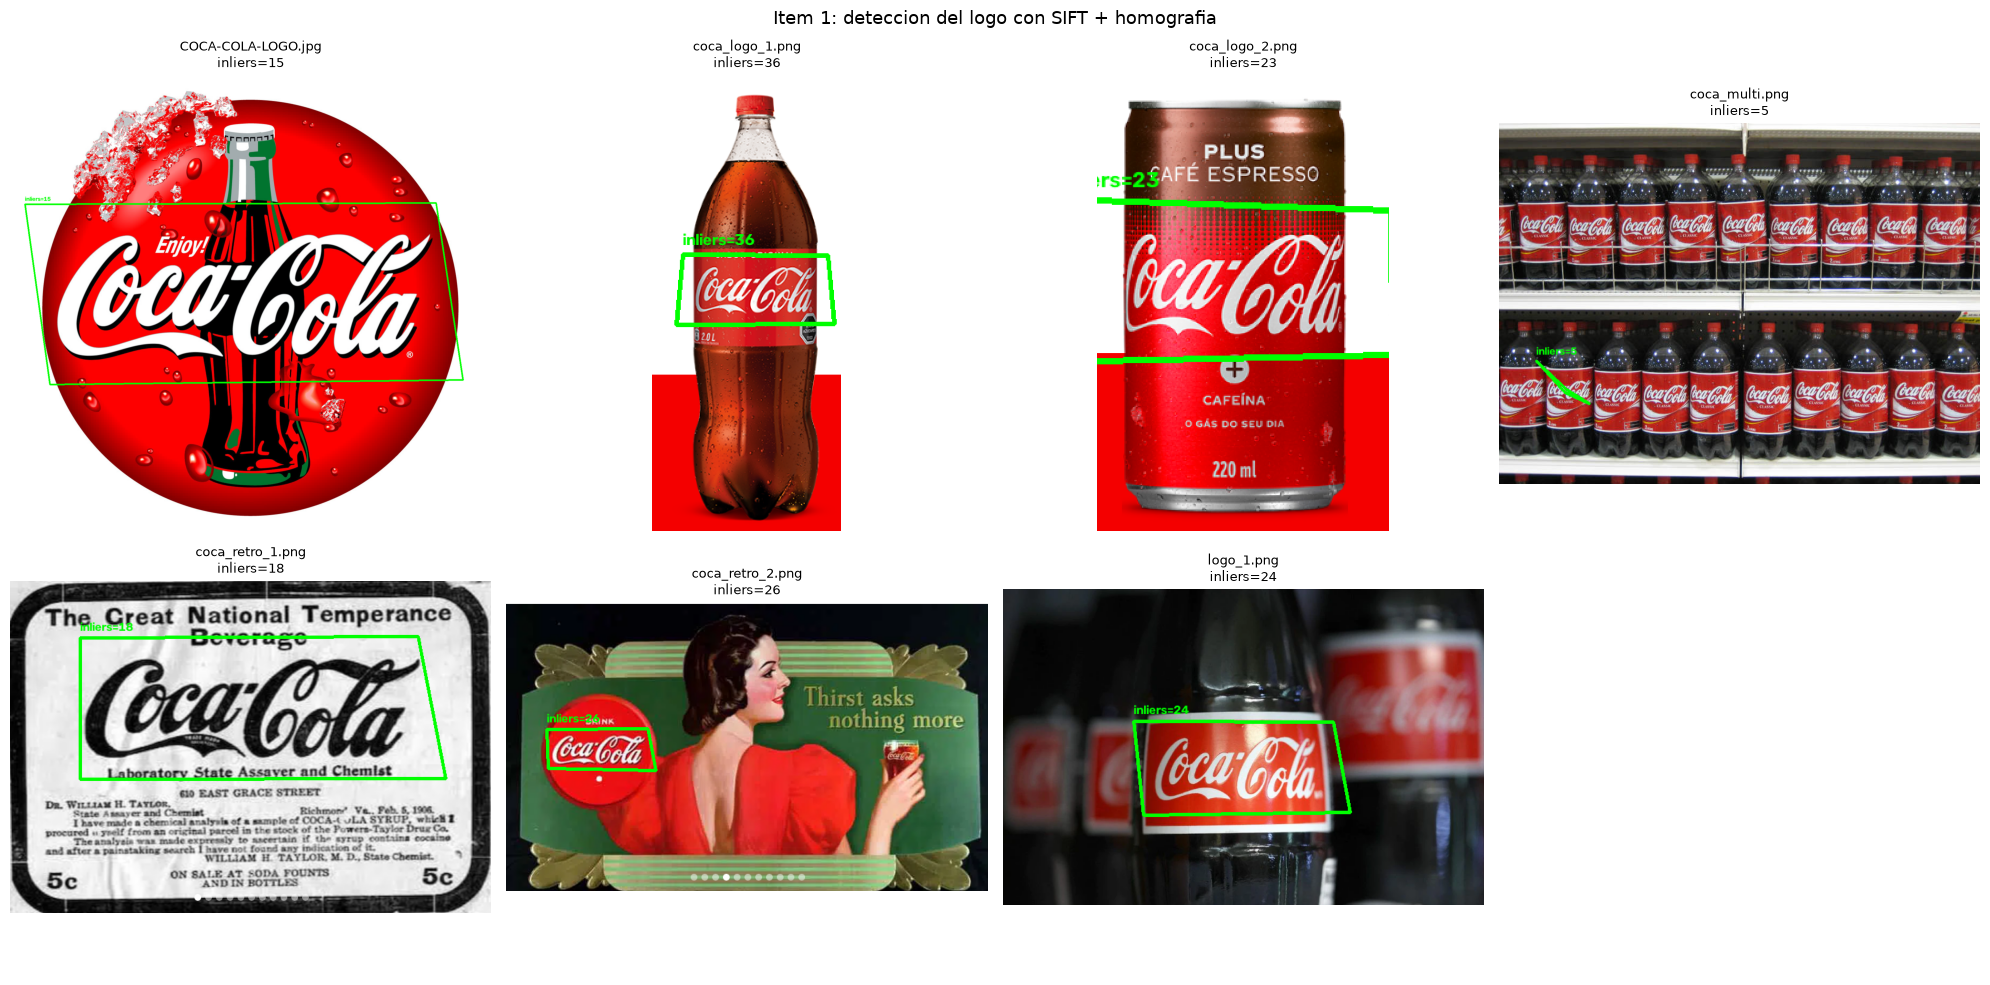

In [ ]:
# En este bloque resolvemos el item 1: una sola deteccion por imagen.
fig, axs = plt.subplots(2, 4, figsize=(20, 10))
axs = axs.flatten()
for i, name in enumerate(image_paths):
    img_gray = images_gray[name]
    n_inliers, quad, H, good = detect_logo_features(
        img_gray,
        sift,
        flann_sift,
        kp_sift_n,
        des_sift_n,
        kp_sift_i,
        des_sift_i,
        template_gray.shape,
    )
    img_draw = draw_quad(images_rgb[name], quad, n_inliers)
    axs[i].imshow(img_draw)
    axs[i].set_title(f'{name}\ninliers={n_inliers}', fontsize=9)
    axs[i].axis('off')
for j in range(i + 1, len(axs)):
    axs[j].axis('off')
plt.suptitle('Item 1: deteccion del logo con SIFT + homografia', fontsize=13)
plt.tight_layout()
plt.show()

## 4. Item 2: multiples detecciones en `coca_multi.png`

Instancias detectadas en coca_multi.png: 19
  Deteccion 1: inliers=27, esquina sup-izq=(65,418)
  Deteccion 2: inliers=26, esquina sup-izq=(232,425)
  Deteccion 3: inliers=24, esquina sup-izq=(442,145)
  Deteccion 4: inliers=23, esquina sup-izq=(25,145)
  Deteccion 5: inliers=22, esquina sup-izq=(-8,416)
  Deteccion 6: inliers=21, esquina sup-izq=(107,147)
  Deteccion 7: inliers=21, esquina sup-izq=(363,139)
  Deteccion 8: inliers=21, esquina sup-izq=(560,426)
  Deteccion 9: inliers=20, esquina sup-izq=(305,420)
  Deteccion 10: inliers=20, esquina sup-izq=(274,143)
  Deteccion 11: inliers=19, esquina sup-izq=(150,419)
  Deteccion 12: inliers=19, esquina sup-izq=(194,148)
  Deteccion 13: inliers=18, esquina sup-izq=(700,146)
  Deteccion 14: inliers=17, esquina sup-izq=(620,144)
  Deteccion 15: inliers=16, esquina sup-izq=(404,426)
  Deteccion 16: inliers=16, esquina sup-izq=(480,419)
  Deteccion 17: inliers=16, esquina sup-izq=(539,148)
  Deteccion 18: inliers=16, esquina sup-izq=(730,4

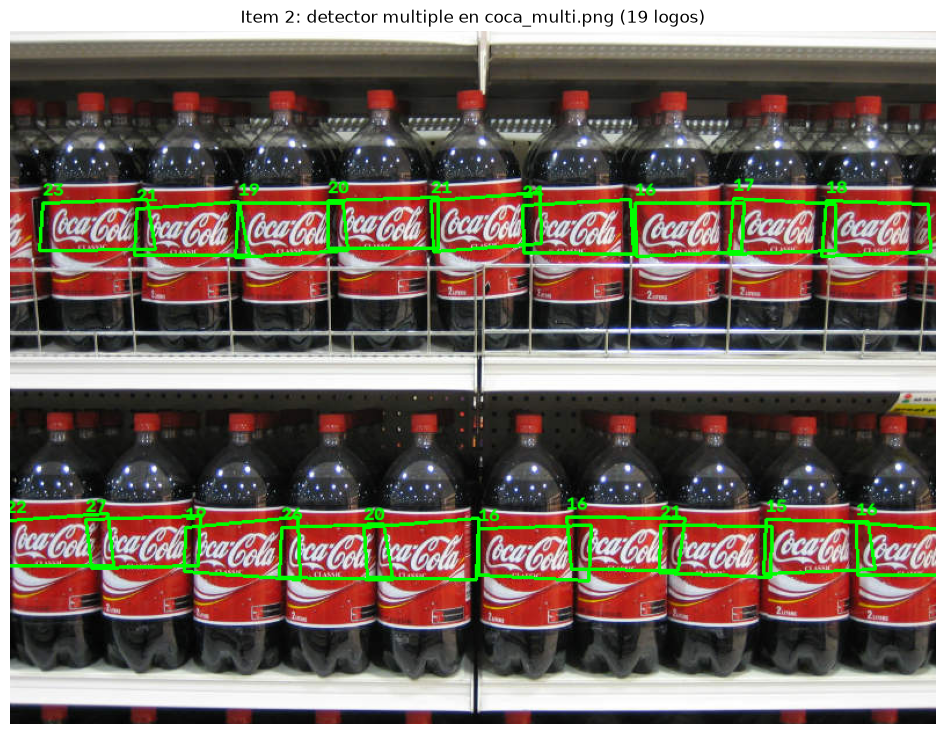

In [ ]:
# En este bloque validamos el caso con varias apariciones del mismo logo.
detections_multi = detect_logos_unified(
    images_gray['coca_multi.png'],
    kp_sift_n,
    des_sift_n,
    kp_sift_i,
    des_sift_i,
    template_gray.shape,
    sift,
)

print(f'Instancias detectadas en coca_multi.png: {len(detections_multi)}')
for i, (quad, n_in) in enumerate(sorted(detections_multi, key=lambda d: -d[1])):
    x0, y0 = quad.reshape(-1, 2).min(0)
    print(f'  Deteccion {i+1}: inliers={n_in}, esquina sup-izq=({int(x0)},{int(y0)})')

img_draw = draw_quads(images_rgb['coca_multi.png'], detections_multi)
plt.figure(figsize=(14, 9))
plt.imshow(img_draw)
plt.title(f'Item 2: detector multiple en coca_multi.png ({len(detections_multi)} logos)')
plt.axis('off')
plt.show()

## 5. Item 3: generalizacion a todas las imagenes

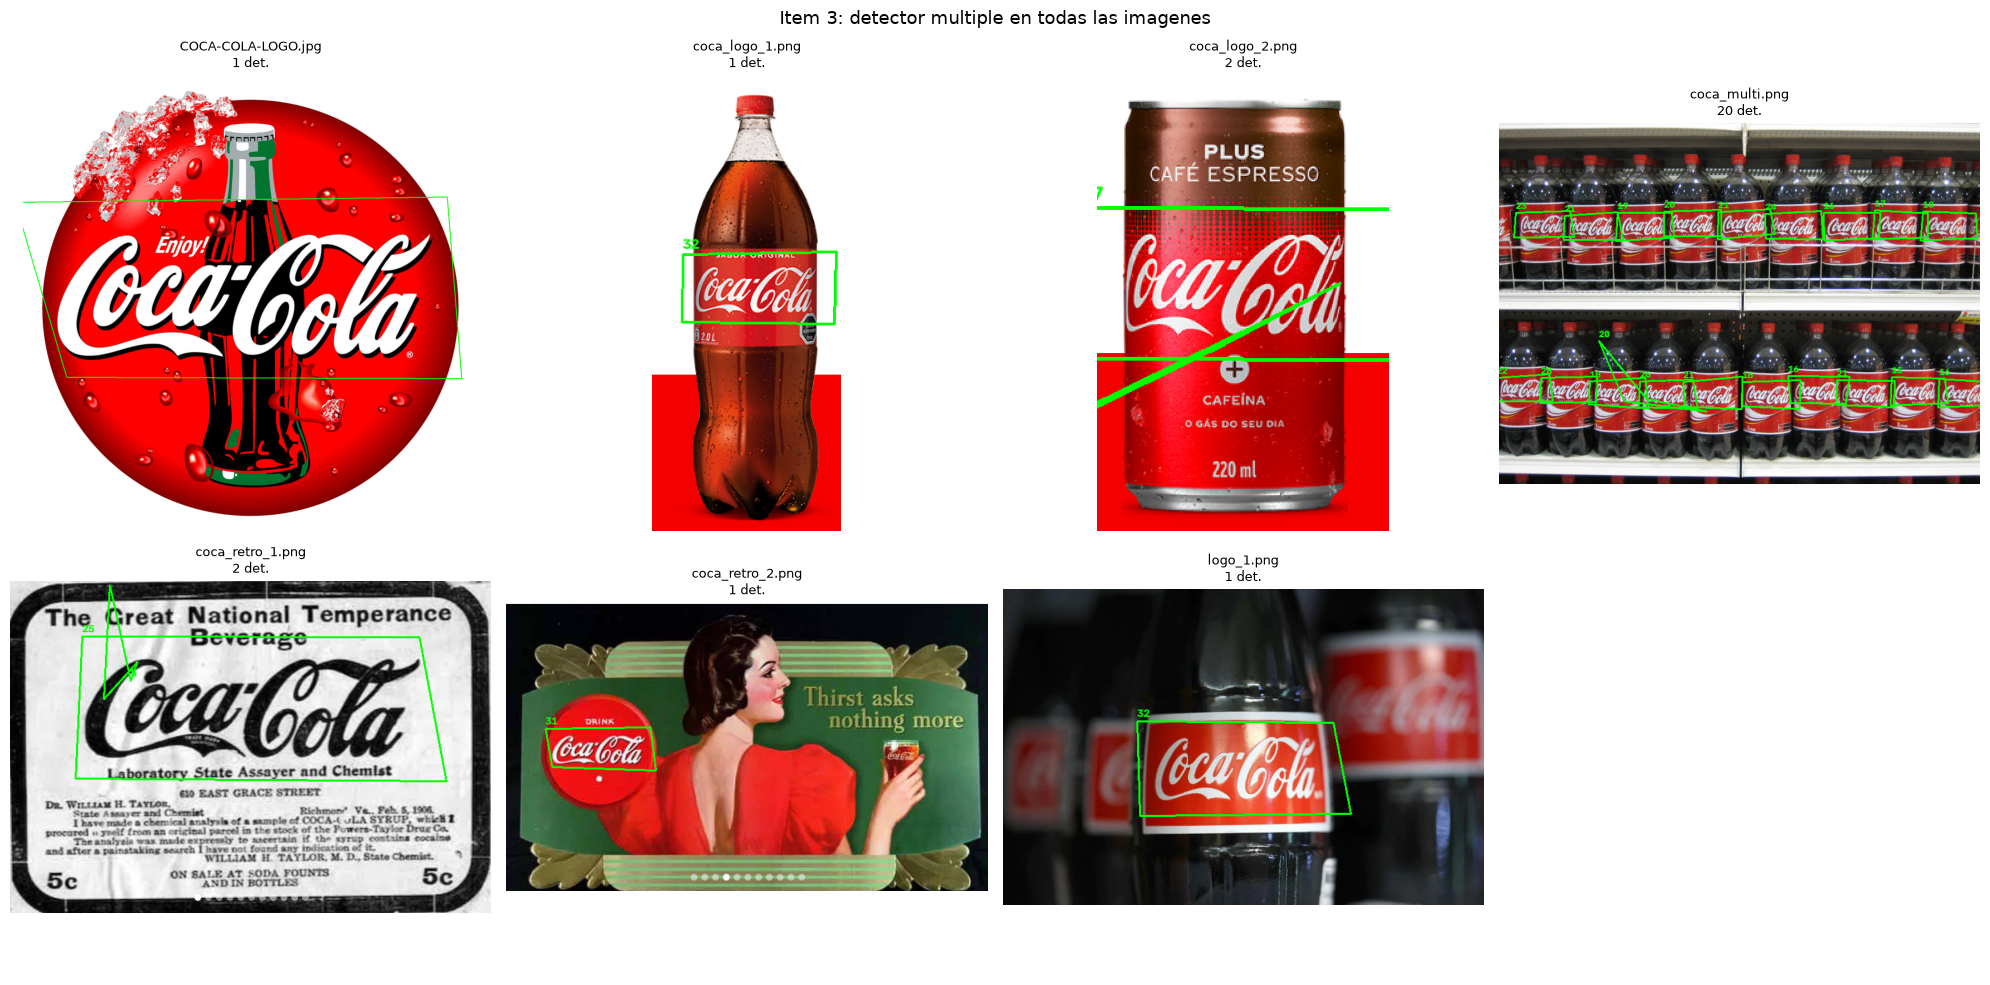

In [ ]:
# En este bloque reutilizamos el mismo detector para todo el conjunto de imagenes.
fig, axs = plt.subplots(2, 4, figsize=(20, 10))
axs = axs.flatten()
for i, name in enumerate(image_paths):
    detections = detect_logos_unified(
        images_gray[name],
        kp_sift_n,
        des_sift_n,
        kp_sift_i,
        des_sift_i,
        template_gray.shape,
        sift,
    )
    img_draw = draw_quads(images_rgb[name], detections)
    axs[i].imshow(img_draw)
    axs[i].set_title(f'{name}\n{len(detections)} det.', fontsize=9)
    axs[i].axis('off')
for j in range(i + 1, len(axs)):
    axs[j].axis('off')
plt.suptitle('Item 3: detector multiple en todas las imagenes', fontsize=13)
plt.tight_layout()
plt.show()